# **Course 5 - Deep Learning and Reinforcement Learning**

**Fruit Classification with Transfer Learning Project**


## **Introduction and Main Objective**

For stakeholders such as grocery retailers, warehouse operations teams, or analytics leaders, an accurate fruit classification model can support automated inventory labeling, quality control workflows, and faster image-based product verification. The main business value is reducing manual classification effort while improving consistency in recognizing visually similar produce classes.

The objective of this project is to build and evaluate a supervised deep learning image classification model that identifies fruit categories from photographs in the Fruits-360 dataset. The analysis focuses on convolutional neural networks (CNNs), including a custom CNN baseline and transfer learning with VGG16. This approach is appropriate because CNN-based architectures are designed to learn visual patterns such as color, texture, edges, and shape directly from image pixels.

## **Dataset Description**

This project uses the **Fruits-360 original-size** image dataset. The dataset is organized into directory-based class labels, where each fruit category has its own folder. The local dataset used in this notebook contains:

- **Training set:** 6,231 images
- **Validation set:** 3,114 images
- **Test set:** 3,110 images
- **Number of classes:** 24 fruit categories

Each observation is an image, and the target variable is the fruit class inferred from the folder name. The image classes include several visually similar categories, such as different apple varieties, which makes this a meaningful multi-class computer vision problem rather than a simple color-matching task.

The goal of the analysis is to train a model that generalizes to unseen fruit images, not merely one that memorizes the training set. For that reason, the notebook uses separate training, validation, and test folders.

## **Data Exploration, Cleaning, and Feature Engineering**

The dataset was reviewed through its directory structure and image generators. Because the labels are encoded in folder names, no separate tabular label-cleaning step was required. The main preparation actions were image-focused:

- Images were resized to **64 x 64** pixels so they could be processed consistently by the neural network.
- Pixel values were rescaled from the 0-255 range to the 0-1 range to improve training stability.
- Training images were augmented using rotation, width and height shifts, shear, zoom, and horizontal flips.
- Validation and test images were only rescaled, not augmented, so evaluation reflects the original held-out data.

These preprocessing choices act as feature engineering for image data. The CNN learns hierarchical visual features from normalized pixels, and augmentation exposes the model to reasonable variations in fruit position and orientation.

## **Notebook Setup**

#### **Prerequisites** 

- Basic knowledge of Python and Keras. 

- TensorFlow installed in your Python environment. 

- A data set of fruit images organized in subdirectories for each class. 


#### **Code to suppress warnings**


In [48]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="keras.src.trainers.data_adapters.py_dataset_adapter",
)
warnings.filterwarnings(
    "ignore", category=UserWarning, module="keras.src.trainers.epoch_iterator"
)

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = (
    "2"  # Suppress all warnings and info messages
)

#### **Required libraries** 

Install the following libraries, if you haven't already: 


In [49]:
# !pip install tensorflow==2.16.2
# !pip install matplotlib==3.9.2
# !pip install numpy==1.26.4
# !pip install scipy==1.14.1
# !pip install scikit-learn==1.5.2

### **Data preparation** 


Directory structure:

The Fruits-360 dataset used in this notebook is organized as follows:

```text
fruits-360-original-size/
`-- fruits-360-original-size/
    |-- Training/
    |   |-- Class1/
    |   |-- Class2/
    |   `-- ...
    |-- Validation/
    |   |-- Class1/
    |   |-- Class2/
    |   `-- ...
    `-- Test/
        |-- Class1/
        |-- Class2/
        `-- ...
```

Each class folder contains images for one fruit category, and the folder name is used as the class label.

## **Analysis Workflow**

The notebook implements the report analysis through the following workflow:

1. [Import libraries and set dataset paths](#import-libraries).
2. [Set up image datasets for training, validation, and testing with augmentation](#setup-image-datasets).
3. [Build and train a custom CNN baseline model](#custom-cnn-baseline).
4. [Define the VGG16-based model architecture with custom layers](#vgg16-architecture).
5. [Compile the model with appropriate loss and optimizer](#compile-model).
6. [Train the model with early stopping and learning rate scheduling](#train-model).
7. [Fine-tune the model by unfreezing specific layers in VGG16](#fine-tune-vgg16).
8. [Evaluate the model on the test set and display accuracy](#evaluate-model).
9. [Visualize training performance with accuracy and loss curves](#visualize-training-performance).
10. [Test model predictions on sample images and visualize results](#sample-predictions).
11. Summarize [modeling comparison and recommendation](#modeling-comparison), [key findings and insights](#key-findings), and [conclusion, limitations, and next steps](#conclusion-next-steps).

### **Download the input data file**

Note: The dataset download may take up to 30 minutes depending on your internet connection. Please ensure a stable connection and wait until the download completes.



In [50]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

# Define dataset URL and paths
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4yIRGlIpNfKEGJYMhZV52g/fruits-360-original-size.zip"
zip_path = Path("fruits-360-original-size.zip")
extract_dir = Path("fruits-360-original-size")

# Download and extract dataset if needed
if extract_dir.exists():
    print("Dataset already extracted.")
else:
    if not zip_path.exists():
        print("Downloading the dataset...")
        urlretrieve(url, zip_path)
        print("Download completed.")
    else:
        print("Dataset already downloaded.")

    print("Extracting the dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print(f"Dataset successfully extracted to '{extract_dir}'.")

# Clean up zip file
if zip_path.exists():
    zip_path.unlink()
    print(f"Cleaned up zip file: {zip_path}")

Dataset already extracted.


<a id="import-libraries"></a>
### **Import libraries and set dataset paths**


This step imports the required Python libraries and defines the paths to the training, validation, and test datasets. These libraries are used to load and process the images, build the deep learning model, train the model, and evaluate its performance.

In [51]:
# Standard library
import os

# Data handling and visualization
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Keras utilities and model components
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
)
from tensorflow.keras.mixed_precision import set_global_policy
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reproducibility and shared image settings
SEED = 42
BATCH_SIZE = 16
IMG_SIZE = (64, 64)
tf.keras.utils.set_random_seed(SEED)

# Dataset paths
dataset_root = "fruits-360-original-size/fruits-360-original-size"
train_dir = os.path.join(dataset_root, "Training")
val_dir = os.path.join(dataset_root, "Validation")
test_dir = os.path.join(dataset_root, "Test")

#### **Explanations**

- `matplotlib` and `numpy`: Support visualization and numerical processing.
- `tensorflow` and Keras: Provide tools for loading image data, building neural networks, training models, and evaluating performance.
- `layers`: Provides Keras preprocessing layers used for image augmentation and rescaling.
- `VGG16`: Provides the pre-trained transfer learning model used for feature extraction.
- `Sequential`: Builds the neural network as a stack of layers.
- `Conv2D`, `MaxPooling2D`, `GlobalAveragePooling2D`, and `Dense`: Define the custom CNN baseline and classification layers.
- `Dropout` and `BatchNormalization`: Help improve training stability and reduce overfitting.
- `ReduceLROnPlateau` and `EarlyStopping`: Help control training by adjusting the learning rate and stopping when validation performance stops improving.
- `SEED`, `BATCH_SIZE`, and `IMG_SIZE`: Store shared settings used throughout the notebook.

<a id="setup-image-datasets"></a>
### **Set up image datasets for training, validation, and testing with augmentation**

This step loads images from the training, validation, and test folders using `image_dataset_from_directory`. The training dataset is shuffled and later augmented to help the model learn more general patterns. The validation and test datasets are not shuffled, which keeps evaluation consistent.

In [52]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

Found 6231 files belonging to 24 classes.
Found 3114 files belonging to 24 classes.
Found 3110 files belonging to 24 classes.
Number of classes: 24


In [53]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.2),
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(height_factor=0.2, width_factor=0.1),
    ]
)

rescale = layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(
    lambda images, labels: (
        data_augmentation(rescale(images), training=True),
        labels,
    )
)
val_dataset = val_dataset.map(lambda images, labels: (rescale(images), labels))
test_dataset = test_dataset.map(lambda images, labels: (rescale(images), labels))

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

#### **Explanation:**

- `image_dataset_from_directory`: Loads images directly from folders and assigns labels based on folder names.
- `label_mode="categorical"`: Converts class labels into one-hot encoded vectors for multi-class classification.
- `class_names` and `num_classes`: Store the class labels and number of output categories used by the model.
- `data_augmentation`: Applies random transformations only to training images to reduce overfitting.
- `rescale`: Converts pixel values from the 0-255 range to the 0-1 range.
- `prefetch`: Improves input pipeline performance by preparing the next batch while the model is training.

<a id="custom-cnn-baseline"></a>
### **Build and train a custom CNN baseline model**


Before using transfer learning, a small CNN baseline is trained from scratch. This gives a simple benchmark for comparison and helps show whether the pre-trained VGG16 model provides a meaningful performance improvement.


In [54]:
# Build a small CNN baseline model from scratch
baseline_model = Sequential(
    [
        Input(shape=(*IMG_SIZE, 3)),
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation="relu"),
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(num_classes, activation="softmax"),
    ]
)

baseline_model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    train_dataset,
    epochs=5,
    steps_per_epoch=50,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    ],
    verbose=2,
)

baseline_final_val_accuracy = baseline_history.history["val_accuracy"][-1]
baseline_best_val_accuracy = max(baseline_history.history["val_accuracy"])
print(f"Baseline final validation accuracy: {baseline_final_val_accuracy:.2f}")
print(f"Baseline best validation accuracy: {baseline_best_val_accuracy:.2f}")

Epoch 1/5
50/50 - 1s - 22ms/step - accuracy: 0.0750 - loss: 3.0829 - val_accuracy: 0.1554 - val_loss: 2.9464
Epoch 2/5
50/50 - 1s - 14ms/step - accuracy: 0.1450 - loss: 2.6631 - val_accuracy: 0.3067 - val_loss: 2.2497
Epoch 3/5
50/50 - 1s - 14ms/step - accuracy: 0.2500 - loss: 2.2482 - val_accuracy: 0.3240 - val_loss: 1.8883
Epoch 4/5
50/50 - 1s - 13ms/step - accuracy: 0.2788 - loss: 2.0391 - val_accuracy: 0.3943 - val_loss: 1.7067
Epoch 5/5
50/50 - 1s - 13ms/step - accuracy: 0.3512 - loss: 1.8819 - val_accuracy: 0.3616 - val_loss: 1.6351
Baseline final validation accuracy: 0.36
Baseline best validation accuracy: 0.39


#### **Explanation:**

- `baseline_model`: Defines a simple CNN trained directly on the fruit images without using pre-trained weights.
- `Conv2D` and `MaxPooling2D`: Learn basic visual patterns and reduce image dimensions as the model moves through the network.
- `GlobalAveragePooling2D`: Converts the learned feature maps into a compact feature vector for classification. It is preferred for transfer learning with VGG16 because it reduces the number of parameters, speeds up training, and lowers the risk of overfitting.
- `Dropout`: Reduces overfitting by randomly disabling some neurons during training.
- `baseline_history`: Stores the training and validation results so they can be compared with the VGG16 transfer learning models.

In the recorded baseline run, this model reached a best validation accuracy of approximately **0.39**. This provides a simple benchmark for showing the improvement gained from VGG16 transfer learning.

<a id="vgg16-architecture"></a>
### **Define the VGG16-based model architecture with custom layers**
This step loads the pre-trained VGG16 model without its original classification layers. The convolutional layers of VGG16 are kept frozen and used as a feature extractor, meaning their pre-trained weights are not updated during training. New classification layers are added on top and trained on the fruit dataset to learn the specific fruit categories.


In [55]:
# Load VGG16 with pre-trained weights
base_model = VGG16(
    weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3)
)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Build the model
model = Sequential(
    [
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation="softmax"),
    ]
)

#### **Explanation:**

- `base_model`: Loads the pre-trained VGG16 model without its original classification layers by setting `include_top=False`.

- `for layer in base_model.layers`: Freezes the VGG16 layers so the model keeps the visual features learned from the original training dataset.

- Custom layers: Add new layers on top of VGG16 to adapt the model to the fruit classification task. These layers include feature pooling or flattening, dense layers for classification, `BatchNormalization` to stabilize training, and `Dropout` to reduce overfitting.

<a id="compile-model"></a>
### **Compile the model with appropriate loss and optimizer**


This step configures the model for training by selecting the loss function, optimizer, and evaluation metric. The loss function measures prediction error, the optimizer updates the model weights, and the metric tracks model performance during training.


In [56]:
model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

#### **Explanation:**

- `categorical_crossentropy`: Measures the prediction error for a multi-class classification problem where each image belongs to one fruit category.
- `adam`: Optimizer that updates the model weights during training. It adjusts the learning rate automatically, which helps the model train efficiently.
- `metrics=['accuracy']`: Tracks the percentage of images that the model classifies correctly during training and validation.

<a id="train-model"></a>
### **Train the model with early stopping and learning rate scheduling**


This step trains the model using the training data and checks its performance on the validation data after each epoch. Early stopping is used to stop training when the validation loss no longer improves, which helps prevent overfitting. Learning rate scheduling reduces the learning rate when progress slows, allowing the model to continue improving more carefully.

In [57]:
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6, verbose=1
)
early_stopping = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# Use float32 precision for compatibility
set_global_policy("float32")

steps_per_epoch = 50

history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    callbacks=[lr_scheduler, early_stopping],
    verbose=2,
)

Epoch 1/5
50/50 - 6s - 119ms/step - accuracy: 0.2037 - loss: 2.7724 - val_accuracy: 0.3012 - val_loss: 2.7089 - learning_rate: 0.0010
Epoch 2/5
50/50 - 5s - 108ms/step - accuracy: 0.4525 - loss: 1.8105 - val_accuracy: 0.3548 - val_loss: 2.3290 - learning_rate: 0.0010
Epoch 3/5
50/50 - 5s - 109ms/step - accuracy: 0.5113 - loss: 1.6175 - val_accuracy: 0.3950 - val_loss: 2.0762 - learning_rate: 0.0010
Epoch 4/5
50/50 - 5s - 109ms/step - accuracy: 0.6062 - loss: 1.2709 - val_accuracy: 0.5132 - val_loss: 1.6864 - learning_rate: 0.0010
Epoch 5/5
50/50 - 6s - 111ms/step - accuracy: 0.6812 - loss: 1.0632 - val_accuracy: 0.5520 - val_loss: 1.5048 - learning_rate: 0.0010


#### **Explanation:**

- `ReduceLROnPlateau`: Lowers the learning rate when the validation loss stops improving. This helps the model make smaller weight updates and continue learning more carefully.

- `EarlyStopping`: Stops training when the validation loss does not improve for several epochs. This helps prevent overfitting and keeps the best-performing model weights.

- `model.fit`: Trains the model using batches from `train_dataset` and checks performance on `val_dataset` after each epoch.

<a id="fine-tune-vgg16"></a>
### **Fine-tune the model by unfreezing specific layers in VGG16**

This step fine-tunes the VGG16 model by unfreezing selected layers near the end of the pre-trained base model. These layers are allowed to update their weights during training so the model can better adapt features to the fruit classification task. A low learning rate is used to make small, careful updates and avoid changing the pre-trained weights too aggressively.

**Note:** Fine-tuning can take longer on a CPU-based machine because more model parameters are updated during training.

In [58]:
# Check the number of layers in the base model
num_layers = len(base_model.layers)
print(f"The base model has {num_layers} layers.")

# Unfreeze the last 5 layers for fine-tuning
for layer in base_model.layers[-5:]:
    layer.trainable = True

# Keep any BatchNormalization layers frozen if present
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile the model with a low learning rate for fine-tuning
model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

# Continue training with the configured training steps
history_fine = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    callbacks=[lr_scheduler, early_stopping],
    verbose=2,
)

The base model has 19 layers.
Epoch 1/5
50/50 - 7s - 138ms/step - accuracy: 0.6950 - loss: 0.9560 - val_accuracy: 0.6021 - val_loss: 1.3695 - learning_rate: 1.0000e-05
Epoch 2/5
50/50 - 6s - 125ms/step - accuracy: 0.7312 - loss: 0.8466 - val_accuracy: 0.6230 - val_loss: 1.2495 - learning_rate: 1.0000e-05
Epoch 3/5
50/50 - 6s - 124ms/step - accuracy: 0.7425 - loss: 0.8398 - val_accuracy: 0.7778 - val_loss: 0.7953 - learning_rate: 1.0000e-05
Epoch 4/5
50/50 - 6s - 125ms/step - accuracy: 0.8012 - loss: 0.6899 - val_accuracy: 0.7225 - val_loss: 0.8749 - learning_rate: 1.0000e-05
Epoch 5/5
50/50 - 6s - 126ms/step - accuracy: 0.7950 - loss: 0.6590 - val_accuracy: 0.7421 - val_loss: 0.7546 - learning_rate: 1.0000e-05


#### **Explanation:**

- `base_model.layers[-5:]`: Unfreezes the last five layers of VGG16 so the model can fine-tune higher-level visual features for the fruit classification task.

- Unfreezing only a small number of layers keeps training faster and helps reduce the risk of overfitting.

- `Adam(learning_rate=1e-5)`: Uses a low learning rate so the pre-trained weights are adjusted gradually instead of changing too quickly.

<a id="evaluate-model"></a>
### **Evaluate the model on the test set and display accuracy**


This step evaluates the final trained model on the test dataset, which contains images the model has not seen during training or validation. The test accuracy provides an estimate of how well the model generalizes to new fruit images.

In [59]:
# Evaluate on the full test set
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=2)
print(f"Test Accuracy: {test_accuracy:.2f}")

195/195 - 4s - 22ms/step - accuracy: 0.7444 - loss: 0.7550
Test Accuracy: 0.74


#### **Explanation:**

- `model.evaluate(test_dataset)`: Evaluates the final model on all test images and prints the test accuracy and loss.

<a id="visualize-training-performance"></a>
### **Visualize training performance with accuracy and loss curves**


This step plots the training and validation accuracy and loss for the baseline CNN, the frozen VGG16 model, and the fine-tuned VGG16 model. These curves help compare learning progress across model variations and identify signs of underfitting or overfitting.


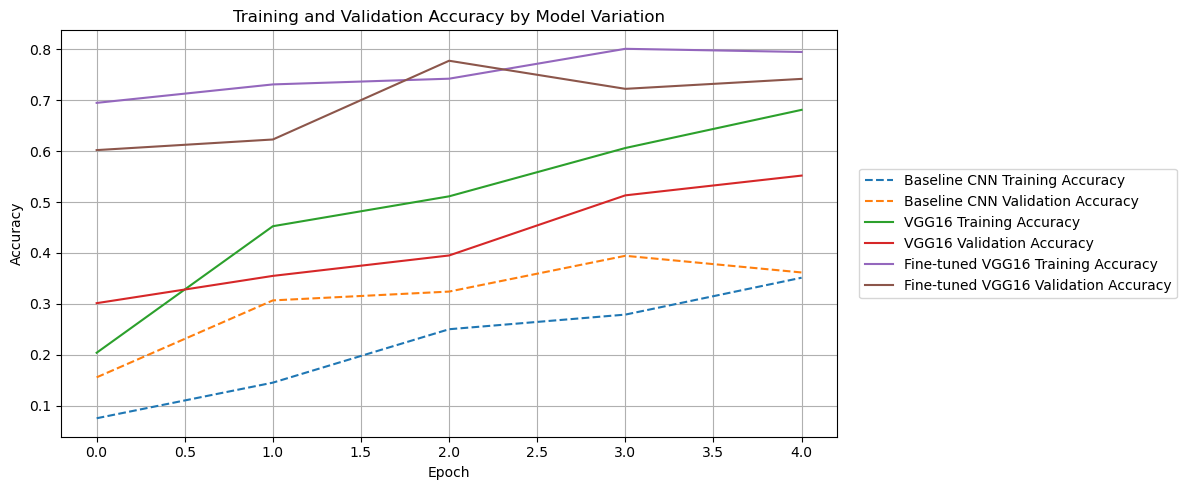

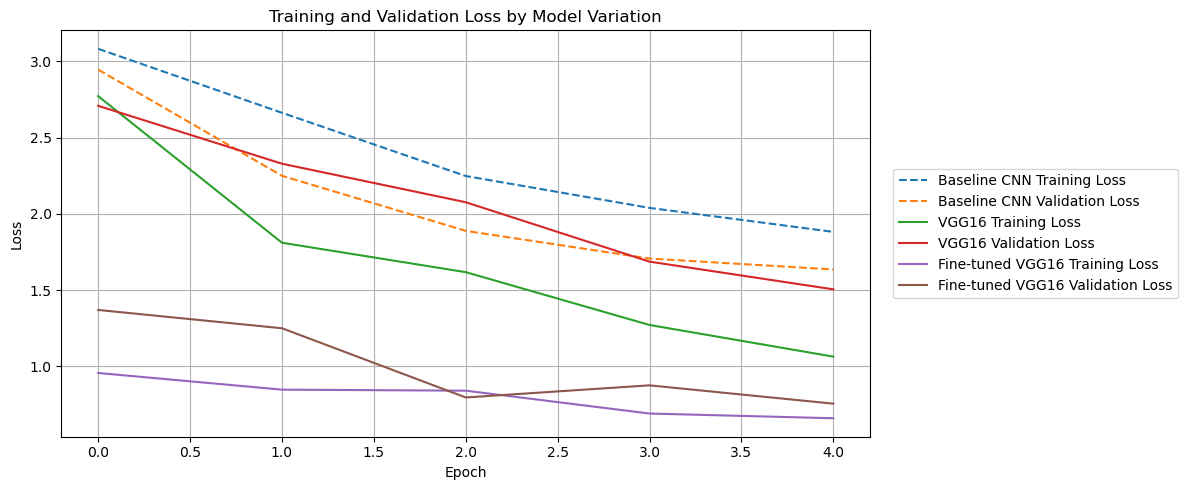

In [60]:
model_histories = {
    "Baseline CNN": baseline_history,
    "VGG16": history,
    "Fine-tuned VGG16": history_fine,
}


def plot_training_curves(metric, ylabel, title):
    plt.figure(figsize=(12, 5))

    for model_name, model_history in model_histories.items():
        linestyle = "--" if model_name == "Baseline CNN" else "-"
        plt.plot(
            model_history.history[metric],
            label=f"{model_name} Training {ylabel}",
            linestyle=linestyle,
        )
        plt.plot(
            model_history.history[f"val_{metric}"],
            label=f"{model_name} Validation {ylabel}",
            linestyle=linestyle,
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_training_curves(
    metric="accuracy",
    ylabel="Accuracy",
    title="Training and Validation Accuracy by Model Variation",
)

plot_training_curves(
    metric="loss",
    ylabel="Loss",
    title="Training and Validation Loss by Model Variation",
)

#### **Explanation:**

- `baseline_history`: Stores the training results for the custom CNN baseline model.
- `history`: Stores the training results for the frozen VGG16 transfer learning model.
- `history_fine`: Stores the training results after fine-tuning selected VGG16 layers.
- The accuracy plot shows how classification performance changes over training.
- The loss plot shows how prediction error changes over training.

<a id="sample-predictions"></a>
### **Test model predictions on sample images and visualize results**

**Explanation:** Makes predictions on a few test images and displays them with the model's predicted class.

Class Index Mapping: {'apple_6': 0, 'apple_braeburn_1': 1, 'apple_crimson_snow_1': 2, 'apple_golden_1': 3, 'apple_golden_2': 4, 'apple_golden_3': 5, 'apple_granny_smith_1': 6, 'apple_hit_1': 7, 'apple_pink_lady_1': 8, 'apple_red_1': 9, 'apple_red_2': 10, 'apple_red_3': 11, 'apple_red_delicios_1': 12, 'apple_red_yellow_1': 13, 'apple_rotten_1': 14, 'cabbage_white_1': 15, 'carrot_1': 16, 'cucumber_1': 17, 'cucumber_3': 18, 'eggplant_violet_1': 19, 'pear_1': 20, 'pear_3': 21, 'zucchini_1': 22, 'zucchini_dark_1': 23}


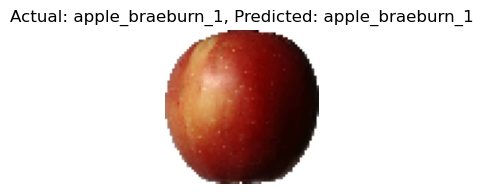

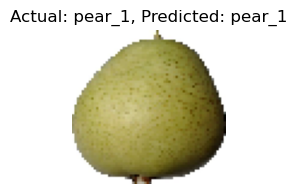

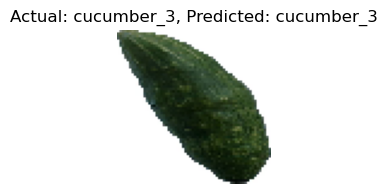

In [61]:
from collections import Counter
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Initialize counters for actual and predicted classes
actual_count = Counter()
predicted_count = Counter()


# Function to get class name from predicted index
def get_class_name_from_index(predicted_index, class_index_mapping):
    """Convert predicted index to class name."""
    for class_name, index in class_index_mapping.items():
        if index == predicted_index:
            return class_name
    return "Unknown"  # Default if index is not found


# Define the function for visualization
def visualize_prediction_with_actual(img_path, class_index_mapping):
    # Extract the true label dynamically from the directory structure
    class_name = os.path.basename(
        os.path.dirname(img_path)
    )  # Extract folder name (class)

    # Load and preprocess the image
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict the class
    prediction = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction, axis=-1)[0]
    predicted_class_name = get_class_name_from_index(
        predicted_index, class_index_mapping
    )

    # Update the counters
    actual_count[class_name] += 1
    predicted_count[predicted_class_name] += 1

    # Visualize the image with predictions
    plt.figure(figsize=(2, 2), dpi=100)
    plt.imshow(img)
    plt.title(f"Actual: {class_name}, Predicted: {predicted_class_name}")
    plt.axis("off")
    plt.show()


# Create class index mapping from the dataset class names
class_index_mapping = {class_name: index for index, class_name in enumerate(class_names)}
print("Class Index Mapping:", class_index_mapping)

# Define a list of image paths without hardcoded labels
sample_images = [
    "fruits-360-original-size/fruits-360-original-size/Test/apple_braeburn_1/r0_11.jpg",
    "fruits-360-original-size/fruits-360-original-size/Test/pear_1/r0_103.jpg",
    "fruits-360-original-size/fruits-360-original-size/Test/cucumber_3/r0_103.jpg",
]

# Run the predictions and visualization
for img_path in sample_images:
    visualize_prediction_with_actual(img_path, class_index_mapping)

<a id="modeling-comparison"></a>
## **Modeling Comparison and Recommendation**

This project compares three deep learning model variations:

| Variation | Model / Training Strategy | Purpose | Recorded Result |
|---|---|---|---|
| 1 | Custom CNN baseline trained from scratch | Establish a simple benchmark without transfer learning | Best validation accuracy: **0.39** |
| 2 | Frozen VGG16 feature extractor with custom classification head | Test whether ImageNet features transfer to fruit images | Validation accuracy: **0.55** |
| 3 | Fine-tuned VGG16 with the last 5 base layers unfrozen | Adapt high-level visual features to fruit-specific patterns | Best validation accuracy: **0.78**; full test accuracy: **0.74** |

All models use categorical cross-entropy because the task is multi-class classification. Accuracy is the primary metric because the classes are mutually exclusive and the project goal is correct image labeling. Loss curves and validation performance are also reviewed to identify overfitting or underfitting.

**The recommended final model is the fine-tuned VGG16 model**, which achieved the strongest validation performance and a full test accuracy of approximately **0.74**. It best fits the project objective because it provides the strongest predictive performance while remaining explainable at a high level: the pre-trained VGG16 layers extract general visual features, and the fine-tuned layers adapt those features to fruit-specific differences. This makes it more suitable than the custom CNN baseline for a stakeholder-facing application where classification reliability matters.

<a id="key-findings"></a>
## **Key Findings and Insights**

The results support three main findings. First, transfer learning is more effective than training a small CNN from scratch for this image classification task. The custom CNN baseline reached a best validation accuracy of about **39%**, while the frozen VGG16 model reached about **55%**.

Second, fine-tuning improved model performance further. Unfreezing the last five VGG16 layers allowed the model to adapt higher-level visual features to the fruit dataset, improving best validation accuracy to about **78%** and producing a full test accuracy of about **74%**.

Third, the most likely errors are expected among visually similar fruit categories. Several classes represent closely related fruit varieties, especially apples, where color and shape differences can be subtle. This matters for stakeholders because the model may perform well overall while still requiring review for categories with high visual similarity.

Sample image predictions provide a qualitative check that the model can map individual unseen images back to their class labels, but the final recommendation should rely primarily on validation and test performance rather than a small number of examples.

<a id="conclusion-next-steps"></a>
## **Conclusion, Limitations, and Next Steps**

**Conclusion:**

The fine-tuned VGG16 transfer learning model achieved the strongest performance among the tested model variations and reached a full test accuracy of approximately **74%**. This result demonstrates that transfer learning is a strong approach for fruit image classification, especially when the available dataset is moderate in size.

**Limitations:**

- The images are relatively standardized, so real-world performance may decline with varied lighting, backgrounds, camera angles, occlusions, or damaged fruit.
- Some fruit classes are visually similar, which may lead to confusion between varieties.
- Accuracy alone does not show which classes are most frequently misclassified; a confusion matrix would provide more detailed diagnostic insight.
- Training used a limited number of training batches per epoch to keep runtime manageable, so broader training and hyperparameter tuning could improve performance.

**Next Steps:**

1. Add a confusion matrix and per-class precision, recall, and F1-score to identify specific fruit categories that need improvement.
2. Train additional transfer learning architectures such as MobileNetV2, ResNet50, or EfficientNet to compare accuracy against model size and inference speed.
3. Expand the dataset with more realistic images from operational environments, including different lighting, backgrounds, ripeness levels, and camera distances.
4. Tune hyperparameters such as learning rate, batch size, augmentation strength, dropout rate, and number of unfrozen layers.
5. Evaluate the final model on the full test set after each major training change and measure prediction latency before using the model in a production or business workflow.

## **Author**

Su Wu
